# MobileNet V2

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [4]:
class InvertedResidual(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ratio):
        super().__init__()
        self.use_residual = (stride == 1 and in_channels == out_channels)
        hidden_dim = in_channels * expand_ratio

        layers = []

        if expand_ratio != 1:
            layers += [
                nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
            ]

        layers += [
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride,
                      padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),

            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        ]

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)

In [5]:
block_residual = InvertedResidual(32, 32, stride=1, expand_ratio=6).to(device)
test_input = torch.randn(2, 32, 56, 56).to(device)
print(f"With residual: {test_input.shape} -> {block_residual(test_input).shape}")
print(f"use_residual = {block_residual.use_residual}")

block_no_residual = InvertedResidual(32, 64, stride=2, expand_ratio=6).to(device)
print(f"\nWithout residual: {test_input.shape} -> {block_no_residual(test_input).shape}")
print(f"use_residual = {block_no_residual.use_residual}")

With residual: torch.Size([2, 32, 56, 56]) -> torch.Size([2, 32, 56, 56])
use_residual = True

Without residual: torch.Size([2, 32, 56, 56]) -> torch.Size([2, 64, 28, 28])
use_residual = False


In [6]:
class MobileNetV2(nn.Module):

    inverted_residual_config = [
        (1,  16, 1, 1),
        (6,  24, 2, 2),
        (6,  32, 3, 2),
        (6,  64, 4, 2),
        (6,  96, 3, 1),
        (6, 160, 3, 2),
        (6, 320, 1, 1),
    ]

    def __init__(self, num_classes=10, width_multiplier=1.0):
        super().__init__()
        alpha = width_multiplier

        def scaled(ch):
            return max(8, int(ch * alpha))

        input_channels = scaled(32)
        last_channels = scaled(1280)

        self.stem = nn.Sequential(
            nn.Conv2d(3, input_channels, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(input_channels),
            nn.ReLU6(inplace=True),
        )

        layers = []
        in_channels = input_channels
        for expand_ratio, out_channels, num_blocks, stride in self.inverted_residual_config:
            out_channels = scaled(out_channels)
            for i in range(num_blocks):
                s = stride if i == 0 else 1
                layers.append(InvertedResidual(in_channels, out_channels, s, expand_ratio))
                in_channels = out_channels

        self.features = nn.Sequential(*layers)

        self.final_conv = nn.Sequential(
            nn.Conv2d(in_channels, last_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(last_channels),
            nn.ReLU6(inplace=True),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(last_channels, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.final_conv(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        x = self.dropout(x)
        return self.fc(x)

model = MobileNetV2(num_classes=10, width_multiplier=1.0).to(device)
print(model)

MobileNetV2(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU6(inplace=True)
  )
  (features): Sequential(
    (0): InvertedResidual(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
        (3): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
 

In [7]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [8]:
def count_conv_params(in_ch, out_ch, kernel_size, groups=1):
    return kernel_size * kernel_size * (in_ch // groups) * out_ch

def count_bn_params(num_features):
    return 2 * num_features


in_ch, out_ch, expand_ratio = 32, 32, 6
hidden_dim = in_ch * expand_ratio  # 192

expand_conv = count_conv_params(in_ch, hidden_dim, 1)
expand_bn = count_bn_params(hidden_dim)
depthwise = count_conv_params(hidden_dim, hidden_dim, 3, groups=hidden_dim)
depthwise_bn = count_bn_params(hidden_dim)
project_conv = count_conv_params(hidden_dim, out_ch, 1)
project_bn = count_bn_params(out_ch)

block_manual = expand_conv + expand_bn + depthwise + depthwise_bn + project_conv + project_bn
block_torch = sum(p.numel() for p in block_residual.parameters())

print(f"Expand (1x1, {in_ch}->{hidden_dim}): {expand_conv:,}")
print(f"Depthwise (3x3, groups={hidden_dim}): {depthwise:,}")
print(f"Project (1x1, {hidden_dim}->{out_ch}): {project_conv:,}")
print(f"\nBlock manual total: {block_manual:,}")
print(f"Block torch total:  {block_torch:,}")
assert block_manual == block_torch, "Mismatch in InvertedResidual parameter count"

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal MobileNetV2 parameters: {total_params:,}")

Expand (1x1, 32->192): 6,144
Depthwise (3x3, groups=192): 1,728
Project (1x1, 192->32): 6,144

Block manual total: 14,848
Block torch total:  14,848

Total MobileNetV2 parameters: 2,236,682


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [11]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=2.0971 train_acc=0.2358 | val_loss=1.9065 val_acc=0.3241 | time=67.6s
Epoch 2/10 | train_loss=1.8665 train_acc=0.3409 | val_loss=1.7137 val_acc=0.4130 | time=63.8s
Epoch 3/10 | train_loss=1.7119 train_acc=0.4050 | val_loss=1.6212 val_acc=0.4504 | time=63.4s
Epoch 4/10 | train_loss=1.5996 train_acc=0.4500 | val_loss=1.4426 val_acc=0.5162 | time=63.7s
Epoch 5/10 | train_loss=1.5309 train_acc=0.4848 | val_loss=1.3811 val_acc=0.5442 | time=63.5s
Epoch 6/10 | train_loss=1.4705 train_acc=0.5104 | val_loss=1.2941 val_acc=0.5692 | time=63.4s
Epoch 7/10 | train_loss=1.4022 train_acc=0.5303 | val_loss=1.2470 val_acc=0.5860 | time=63.4s
Epoch 8/10 | train_loss=1.3965 train_acc=0.5318 | val_loss=1.2027 val_acc=0.5997 | time=63.9s
Epoch 9/10 | train_loss=1.3559 train_acc=0.5516 | val_loss=1.1818 val_acc=0.6033 | time=63.9s
Epoch 10/10 | train_loss=1.3010 train_acc=0.5677 | val_loss=1.1377 val_acc=0.6260 | time=63.5s


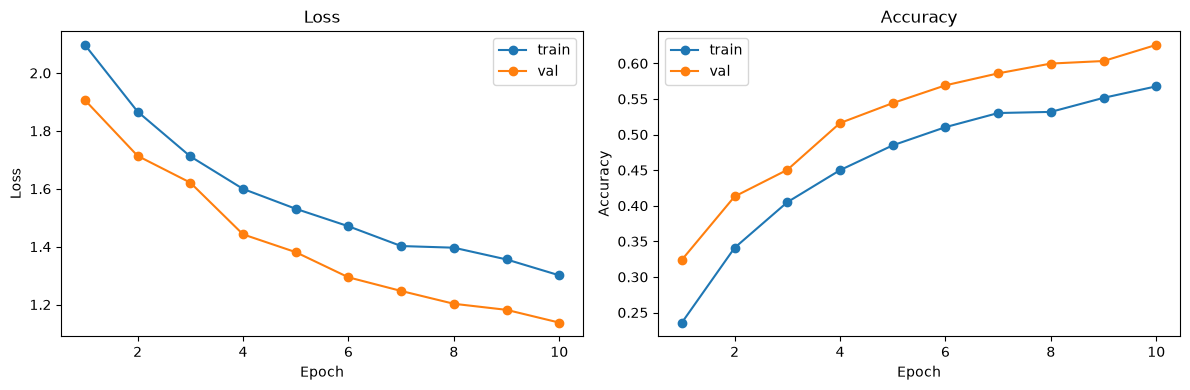

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

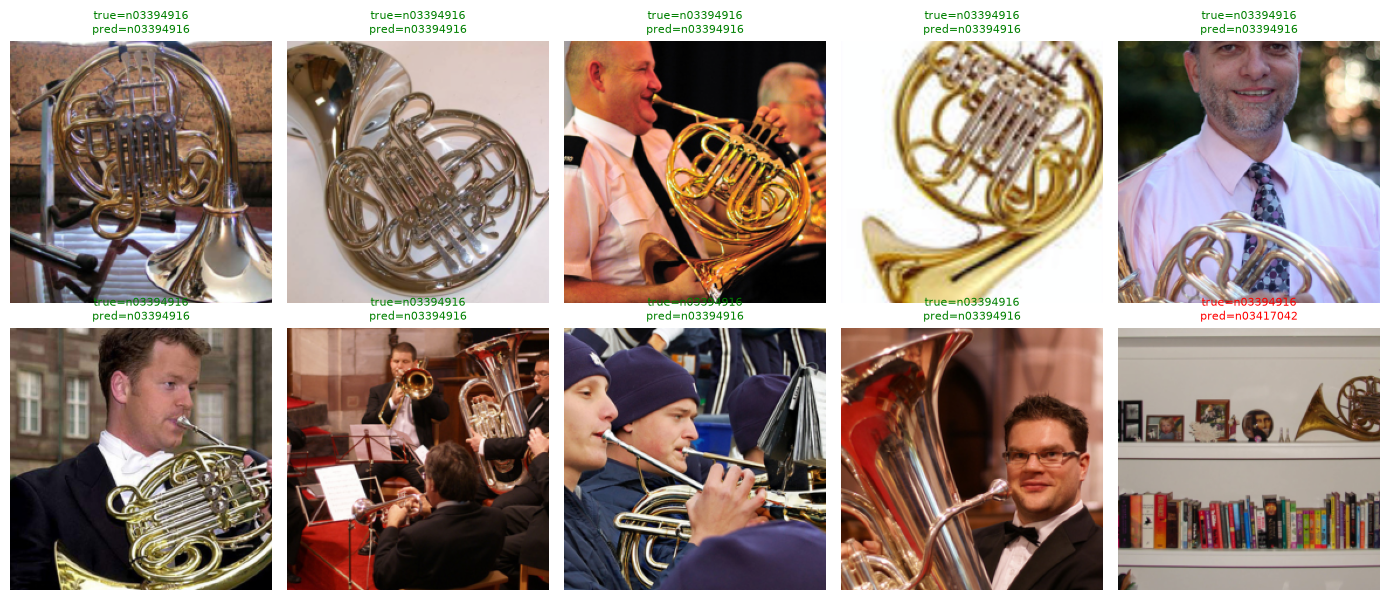

In [13]:
model.eval()

random_batch_idx = random.randint(0, len(val_loader) - 1)
for i, batch in enumerate(val_loader):
    if i == random_batch_idx:
        sample_images, sample_labels = batch
        break

class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: ~V2 -
typically slightly smaller than MobileNetV1 despite the added expansion
step, because the expand-then-project pattern lets most of the network
operate on a compact base width (in_channels), only briefly widening to
hidden_dim=in_channels*6 inside each block, rather than staying wide
throughout like V1's flat depthwise-separable stack.

**Inverted residual - why "inverted".** A standard ResNet/ResNeXt Bottleneck
compresses first (1x1 narrow) then does the expensive operation on the
narrow representation, then expands back. MobileNetV2 does the opposite:
expand first (1x1 wide), do the expensive depthwise op on the WIDE
representation, then project back down - the width profile is inverted
relative to a classic bottleneck, hence the name.

**Linear bottleneck - why no ReLU after projection.** The final 1x1 conv in
each block has no activation. The paper's argument: ReLU zeroes out negative
values, and in a low-dimensional (projected) space this destroys information
that cannot be recovered downstream - unlike in the expanded/wide space,
where enough redundant dimensions exist that some can be safely zeroed
without losing the underlying signal.

**Why Adam instead of RMSProp.** The original paper used RMSProp, similar
to MobileNetV1. We used Adam for simpler, more reliable convergence without
manual tuning.